# Explore KITTI dataset

The KITTI object detection data lives in `./data/KITTI/object/training` with the following subfolders (see `README.md`):

- `origin_2/` &mdash; clear (RGB) images
- `foggy_2/` &mdash; adverse-weather (foggy) images
- `velodyne/` &mdash; LiDAR point-cloud frames
- `label_2/` &mdash; ground-truth labels
- `calib/` &mdash; calibration files

In [10]:
from pathlib import Path

# Resolve the training dir relative to the repo root, whether the notebook is run
# from notebooks/ or from the repo root.
candidates = [
    Path("../data/KITTI/object/training"),
    Path("data/KITTI/object/training"),
]
training_dir = next((p for p in candidates if p.is_dir()), candidates[0])
training_dir = training_dir.resolve()
print(f"Training dir: {training_dir}")

# folder name -> (description, file extension)
folders = {
    "origin_2": ("clear images", ".png"),
    "foggy_2": ("foggy images", ".png"),
    "velodyne": ("velodyne frames", ".bin"),
    "label_2": ("labels", ".txt"),
}

counts = {}
for folder, (desc, ext) in folders.items():
    path = training_dir / folder
    n = len(list(path.glob(f"*{ext}"))) if path.is_dir() else None
    counts[folder] = n
    status = n if n is not None else "MISSING"
    print(f"{folder:<10} ({desc:<15}): {status}")

# Verify all folders exist and hold the same number of frames.
missing = [f for f, n in counts.items() if n is None]
assert not missing, f"Missing folder(s): {missing}"

unique_counts = set(counts.values())
assert len(unique_counts) == 1, f"Frame counts differ across folders: {counts}"

print(f"\nAll folders contain the same number of frames: {unique_counts.pop()}")

Training dir: /workspace/data/KITTI/object/training
origin_2   (clear images   ): 7481
foggy_2    (foggy images   ): 7481
velodyne   (velodyne frames): 7481
label_2    (labels         ): 7481

All folders contain the same number of frames: 7481


Showing frame 000000


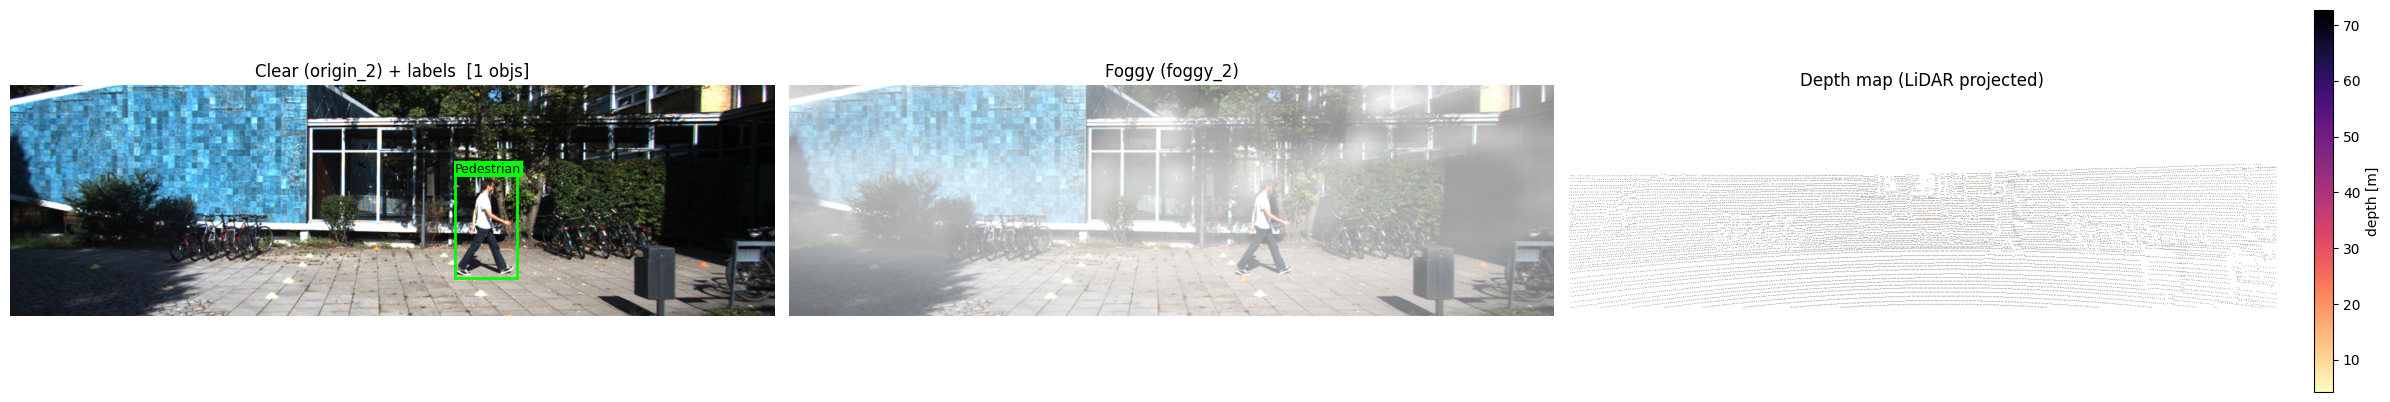

In [11]:
import sys

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Make visualDet3D importable, whether the notebook runs from notebooks/ or the repo root.
repo_root = training_dir.parents[3]  # .../object/training -> repo root
for p in (str(repo_root), str(Path.cwd().parent), str(Path.cwd())):
    if p not in sys.path:
        sys.path.insert(0, p)

from visualDet3D.data.kitti.kittidata import KittiData
from visualDet3D.data.kitti.utils import generate_depth_from_velo

# --- Pick a frame -----------------------------------------------------------
# Use the first available index in origin_2 (or set INDEX manually e.g. "000008").
INDEX = sorted(p.stem for p in (training_dir / "origin_2").glob("*.png"))[0]
print(f"Showing frame {INDEX}")

root_dir = str(training_dir)
data = KittiData(root_dir, INDEX)
calib, clear_img, label, pc, foggy_img = data.read_data()

# --- Build the depth map by projecting the LiDAR point cloud onto the image -
h, w = clear_img.shape[:2]
depth_map = generate_depth_from_velo(
    pc[:, :3], h, w,
    calib.Tr_velo_to_cam, calib.R0_rect, calib.P2,
)
depth_map = np.ma.masked_equal(depth_map, 0)  # hide pixels with no LiDAR return

# --- Plot: clear+labels | foggy | depth -------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# 1) clear image with 2D ground-truth boxes
axes[0].imshow(clear_img)
for obj in label.data:
    rect = patches.Rectangle(
        (obj.bbox_l, obj.bbox_t),
        obj.bbox_r - obj.bbox_l, obj.bbox_b - obj.bbox_t,
        linewidth=2, edgecolor="lime", facecolor="none",
    )
    axes[0].add_patch(rect)
    axes[0].text(
        obj.bbox_l, obj.bbox_t - 4, obj.type,
        color="black", fontsize=9,
        bbox=dict(facecolor="lime", edgecolor="none", pad=1),
    )
axes[0].set_title(f"Clear (origin_2) + labels  [{len(label.data)} objs]")
axes[0].axis("off")

# 2) foggy image
axes[1].imshow(foggy_img)
axes[1].set_title("Foggy (foggy_2)")
axes[1].axis("off")

# 3) depth map from LiDAR
im = axes[2].imshow(depth_map, cmap="magma_r")
axes[2].set_title("Depth map (LiDAR projected)")
axes[2].axis("off")
fig.colorbar(im, ax=axes[2], fraction=0.025, label="depth [m]")

plt.tight_layout()
plt.show()

## Distribution of image sizes (origin_2)

Count how many images share each `(width, height)` resolution in the clear-image folder.

7481 images across 4 distinct resolution(s):

width x height     count    share
1242 x 375          6057   81.0%
1224 x 370           770   10.3%
1238 x 374           358    4.8%
1241 x 376           296    4.0%

width : min=1224  max=1242  mean=1239.9
height: min=370  max=376  mean=374.5


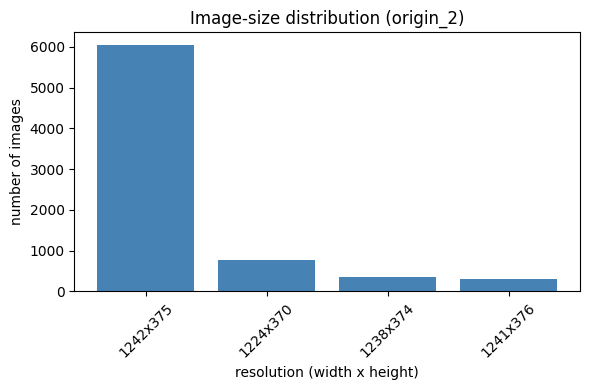

In [12]:
from collections import Counter
from PIL import Image

origin_dir = training_dir / "origin_2"
paths = sorted(origin_dir.glob("*.png"))

# Image.open is lazy -> .size reads only the header, no full decode.
size_counts = Counter()
for p in paths:
    with Image.open(p) as im:
        size_counts[im.size] += 1  # (width, height)

total = sum(size_counts.values())
print(f"{total} images across {len(size_counts)} distinct resolution(s):\n")
print(f"{'width x height':<16}{'count':>8}{'share':>9}")
for (w, h), n in size_counts.most_common():
    print(f"{f'{w} x {h}':<16}{n:>8}{n / total:>8.1%}")

widths = np.array([w for (w, h), n in size_counts.items() for _ in range(n)])
heights = np.array([h for (w, h), n in size_counts.items() for _ in range(n)])
print(f"\nwidth : min={widths.min()}  max={widths.max()}  mean={widths.mean():.1f}")
print(f"height: min={heights.min()}  max={heights.max()}  mean={heights.mean():.1f}")

# Bar chart of resolutions (sorted by frequency).
labels = [f"{w}x{h}" for (w, h), _ in size_counts.most_common()]
values = [n for _, n in size_counts.most_common()]
fig, ax = plt.subplots(figsize=(max(6, len(labels) * 0.6), 4))
ax.bar(labels, values, color="steelblue")
ax.set_ylabel("number of images")
ax.set_xlabel("resolution (width x height)")
ax.set_title("Image-size distribution (origin_2)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Label class distribution (label_2)

Count object instances per class across all label files (`DontCare` included for completeness).

51865 objects across 7481 frames, 9 classes:

class              count    share
Car                28742   55.4%
DontCare           11295   21.8%
Pedestrian          4487    8.7%
Van                 2914    5.6%
Cyclist             1627    3.1%
Truck               1094    2.1%
Misc                 973    1.9%
Tram                 511    1.0%
Person_sitting       222    0.4%


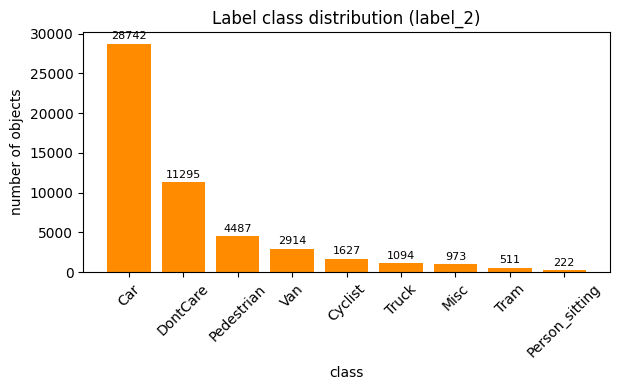

In [13]:
from collections import Counter

from visualDet3D.data.kitti.kittidata import KittiLabel

label_dir = training_dir / "label_2"
label_paths = sorted(label_dir.glob("*.txt"))

class_counts = Counter()
for p in label_paths:
    # no_dontcare=False keeps "DontCare" so the distribution is complete.
    label = KittiLabel(str(p)).read_label_file(no_dontcare=False)
    for obj in label.data:
        class_counts[obj.type] += 1

total = sum(class_counts.values())
print(f"{total} objects across {len(label_paths)} frames, {len(class_counts)} classes:\n")
print(f"{'class':<14}{'count':>10}{'share':>9}")
for cls, n in class_counts.most_common():
    print(f"{cls:<14}{n:>10}{n / total:>8.1%}")

# Bar chart of class counts (sorted by frequency).
labels = [cls for cls, _ in class_counts.most_common()]
values = [n for _, n in class_counts.most_common()]
fig, ax = plt.subplots(figsize=(max(6, len(labels) * 0.7), 4))
bars = ax.bar(labels, values, color="darkorange")
ax.bar_label(bars, fmt="%d", padding=2, fontsize=8)
ax.set_ylabel("number of objects")
ax.set_xlabel("class")
ax.set_title("Label class distribution (label_2)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Object distance distribution (label_2)

Distance of each annotated object from the camera, using the 3D location `(x, y, z)` in camera coordinates (`z` = forward depth). `DontCare` objects are excluded since they carry no valid 3D location.

40570 objects with valid 3D location

distance [m]: min=2.9  max=149.5  mean=29.3  median=25.8
percentiles : 25%=15.4  75%=39.9  95%=62.9


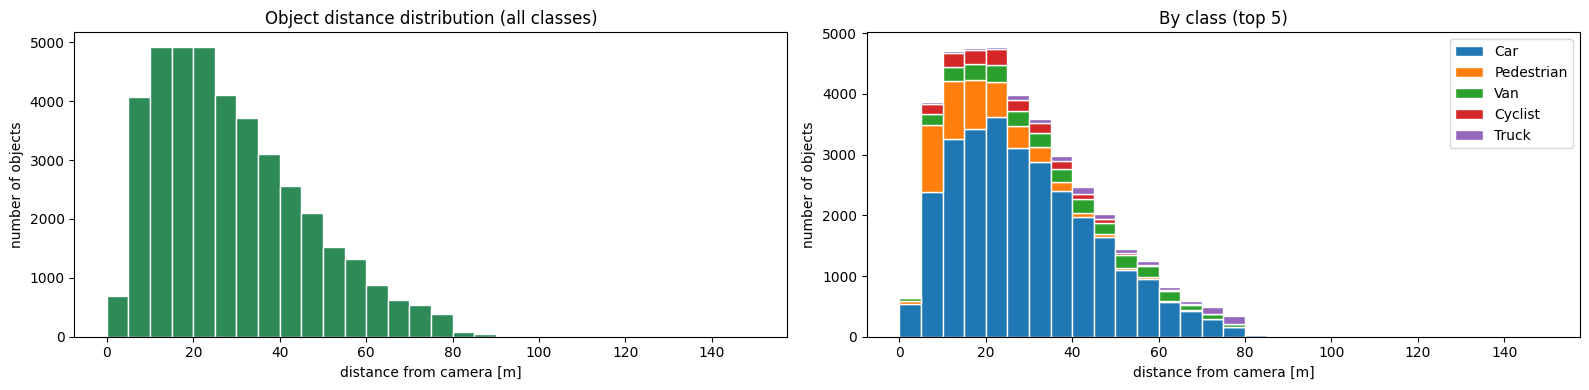

In [14]:
from collections import defaultdict

from visualDet3D.data.kitti.kittidata import KittiLabel

label_dir = training_dir / "label_2"
label_paths = sorted(label_dir.glob("*.txt"))

# Euclidean distance to the camera, collected per class.
dist_by_class = defaultdict(list)
for p in label_paths:
    label = KittiLabel(str(p)).read_label_file(no_dontcare=True)  # drop DontCare (no valid location)
    for obj in label.data:
        dist = float(np.sqrt(obj.x ** 2 + obj.y ** 2 + obj.z ** 2))
        dist_by_class[obj.type].append(dist)

all_dists = np.array([d for ds in dist_by_class.values() for d in ds])
print(f"{len(all_dists)} objects with valid 3D location\n")
print(f"distance [m]: min={all_dists.min():.1f}  max={all_dists.max():.1f}  "
      f"mean={all_dists.mean():.1f}  median={np.median(all_dists):.1f}")
print(f"percentiles : 25%={np.percentile(all_dists, 25):.1f}  "
      f"75%={np.percentile(all_dists, 75):.1f}  95%={np.percentile(all_dists, 95):.1f}")

bins = np.arange(0, all_dists.max() + 5, 5)
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Overall distribution.
axes[0].hist(all_dists, bins=bins, color="seagreen", edgecolor="white")
axes[0].set_xlabel("distance from camera [m]")
axes[0].set_ylabel("number of objects")
axes[0].set_title("Object distance distribution (all classes)")

# Per-class (top classes by count), stacked.
top_classes = sorted(dist_by_class, key=lambda c: -len(dist_by_class[c]))[:5]
axes[1].hist(
    [dist_by_class[c] for c in top_classes],
    bins=bins, stacked=True, label=top_classes, edgecolor="white",
)
axes[1].set_xlabel("distance from camera [m]")
axes[1].set_ylabel("number of objects")
axes[1].set_title("By class (top 5)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Explore the packed HDF5 containers

`scripts/pack_hdf5.py` collapses each split into a single `data.h5` under
`workdirs/MonoWAD/output/{training,validation}/`. The cell below opens each container and
prints its structure (file attributes + every dataset's shape/dtype/compression), then
visualizes one sample frame.

Labels are stored ragged in a `labels` group (`count` per frame, plus flattened
`data` and `type`). Since the runtime derives the 2D box from the 3D box, the overlay
**reprojects each 3D box through the stored post-resize `P2`** — landing the boxes
directly on the baked 288×1280 image, exactly as training does.

/workspace/workdirs/MonoWAD/output/training/data.h5
file size: 6.60 GB

attributes:
  baked_ops     = CropTop,Resize
  count         = 3712
  has_depth     = True
  has_foggy     = True
  has_label     = True
  label_fields  = truncated,occluded,alpha,bbox_l,bbox_t,bbox_r,bbox_b,h,w,l,x,y,z,ry
  split         = training

datasets:
  P2             shape=(3712, 3, 4)           dtype=float32    chunks=None compression=none
  clear          shape=(3712, 288, 1280, 3)   dtype=uint8      chunks=(1, 288, 1280, 3) compression=lzf
  depth          shape=(3712, 72, 320)        dtype=uint8      chunks=(1, 72, 320) compression=lzf
  foggy          shape=(3712, 288, 1280, 3)   dtype=uint8      chunks=(1, 288, 1280, 3) compression=lzf
  frame_id       shape=(3712,)                dtype=object     chunks=None compression=none
  labels/count   shape=(3712,)                dtype=int32      chunks=None compression=none
  labels/data    shape=(11707, 14)            dtype=float32    chunks=(1464, 2) comp

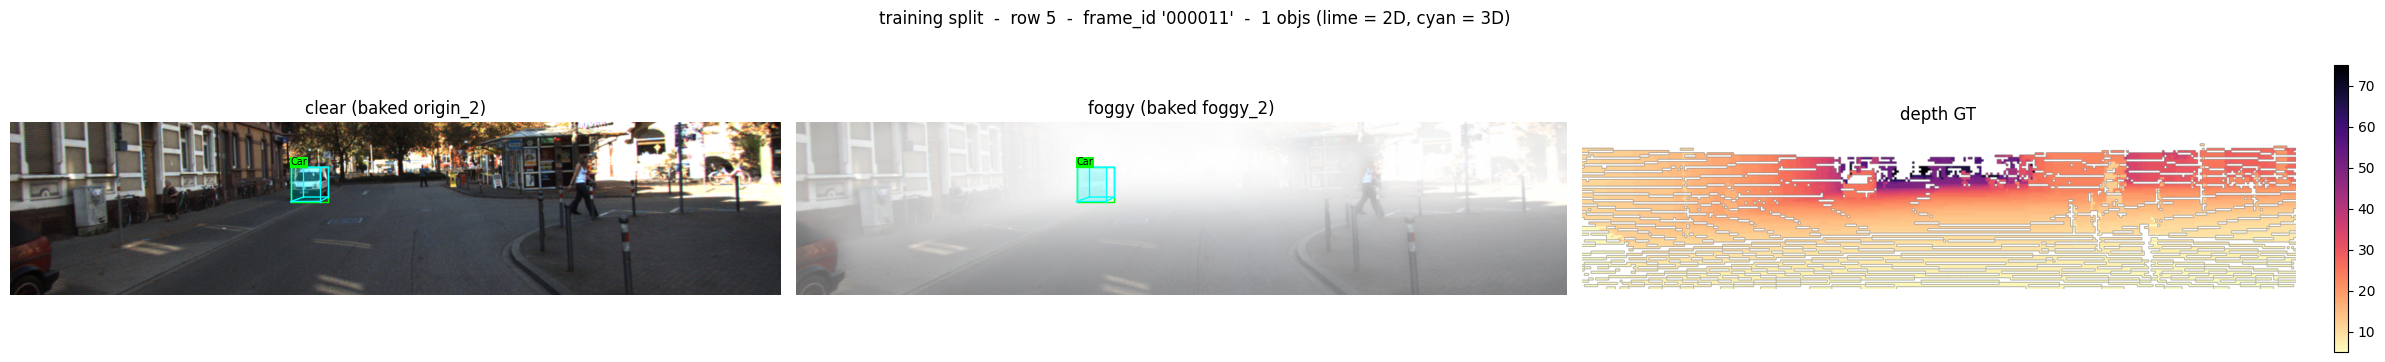


/workspace/workdirs/MonoWAD/output/validation/data.h5
file size: 6.55 GB

attributes:
  baked_ops     = CropTop,Resize
  count         = 3769
  has_depth     = False
  has_foggy     = True
  has_label     = True
  label_fields  = truncated,occluded,alpha,bbox_l,bbox_t,bbox_r,bbox_b,h,w,l,x,y,z,ry
  split         = validation

datasets:
  P2             shape=(3769, 3, 4)           dtype=float32    chunks=None compression=none
  clear          shape=(3769, 288, 1280, 3)   dtype=uint8      chunks=(1, 288, 1280, 3) compression=lzf
  foggy          shape=(3769, 288, 1280, 3)   dtype=uint8      chunks=(1, 288, 1280, 3) compression=lzf
  frame_id       shape=(3769,)                dtype=object     chunks=None compression=none
  labels/count   shape=(3769,)                dtype=int32      chunks=None compression=none
  labels/data    shape=(14385, 14)            dtype=float32    chunks=(1799, 2) compression=lzf
  labels/type    shape=(14385,)               dtype=object     chunks=None compre

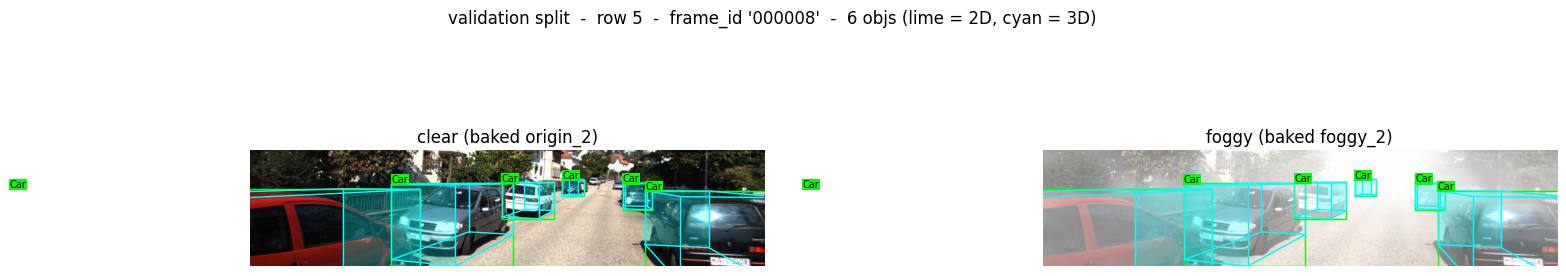

In [18]:
import h5py

output_dir = repo_root / "workdirs" / "MonoWAD" / "output"
h5_paths = {
    "training":   output_dir / "training" / "data.h5",
    "validation": output_dir / "validation" / "data.h5",
}

SAMPLE_IDX = 5  # which row to visualize from each container

# 3D box wireframe topology over the 8 corners produced by box_corners_2d().
BOX_EDGES = [(0, 1), (1, 2), (2, 3), (3, 0),   # bottom face
             (4, 5), (5, 6), (6, 7), (7, 4),   # top face
             (0, 4), (1, 5), (2, 6), (3, 7)]   # verticals


def frame_labels(h5, i):
    """Labels for frame i from the ragged `labels` group -> (rows[k,14], types[k]).

    Frame i owns labels/data[offset:offset+count[i]] with offset = sum(count[:i]).
    """
    if "labels" not in h5:
        return None, None
    counts = h5["labels/count"]
    start = int(np.sum(counts[:i]))
    end = start + int(counts[i])
    types = [t.decode() if isinstance(t, bytes) else t for t in h5["labels/type"][start:end]]
    return h5["labels/data"][start:end], types


def box_corners_2d(P2, row):
    """Project the 8 corners of a 3D box through the stored post-resize P2.
    Returns pixel coords [8, 2] (x, y) in the baked image, or None if behind camera.
    Corner order: 0-3 bottom face, 4-7 top face; front (heading) face = {0,1,5,4}."""
    # LABEL_FIELDS index: 7 h, 8 w, 9 l, 10 x, 11 y, 12 z, 13 ry
    h, w, l, x, y, z, ry = (float(row[k]) for k in (7, 8, 9, 10, 11, 12, 13))
    if z <= 0:
        return None  # behind the camera
    c, s = np.cos(ry), np.sin(ry)
    R = np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])
    xc = np.array([ l/2,  l/2, -l/2, -l/2,  l/2,  l/2, -l/2, -l/2])
    yc = np.array([   0,    0,    0,    0,   -h,   -h,   -h,   -h])
    zc = np.array([ w/2, -w/2, -w/2,  w/2,  w/2, -w/2, -w/2,  w/2])
    corners = R @ np.vstack([xc, yc, zc]) + np.array([[x], [y], [z]])  # [3, 8]
    homo = P2 @ np.vstack([corners, np.ones(8)])                       # [3, 8]
    return (homo[:2] / homo[2]).T                                      # [8, 2]


def draw_boxes(ax, P2, rows, types, draw_2d=True, draw_3d=True):
    for row, cls in zip(rows, types):
        pts = box_corners_2d(P2, row)
        if pts is None:
            continue

        if draw_3d:
            for a, b in BOX_EDGES:
                ax.plot(*zip(pts[a], pts[b]), color="cyan", linewidth=1.0)
            # Shade the front (heading) face so orientation is readable.
            ax.add_patch(patches.Polygon(pts[[0, 1, 5, 4]], closed=True,
                         facecolor="cyan", edgecolor="none", alpha=0.25))

        if draw_2d:
            (l, t), (r, b) = pts.min(0), pts.max(0)  # enclosing 2D box
            ax.add_patch(patches.Rectangle((l, t), r - l, b - t,
                         linewidth=1.0, edgecolor="lime", facecolor="none"))
            ax.text(l, t - 3, cls, color="black", fontsize=7,
                    bbox=dict(facecolor="lime", edgecolor="none", pad=0.5))


def describe_h5(split, path: Path):
    print("=" * 70)
    print(path)
    print("=" * 70)
    if not path.is_file():
        print("  MISSING - run scripts/pack_hdf5.py for this split\n")
        return

    with h5py.File(path, "r") as h5:
        size_gb = path.stat().st_size / 1e9
        print(f"file size: {size_gb:.2f} GB")

        if h5.attrs:
            print("\nattributes:")
            for k, v in h5.attrs.items():
                print(f"  {k:<14}= {v}")

        print("\ndatasets:")
        # visititems walks the full hierarchy (groups + datasets, incl. labels/*).
        def visit(name, obj):
            if isinstance(obj, h5py.Dataset):
                comp = obj.compression or "none"
                print(f"  {name:<14} shape={str(obj.shape):<22} dtype={str(obj.dtype):<10} "
                      f"chunks={obj.chunks} compression={comp}")
        h5.visititems(visit)

        # --- Visualize one sample frame -------------------------------------
        i = SAMPLE_IDX
        fid = h5["frame_id"][i]
        fid = fid.decode() if isinstance(fid, bytes) else fid
        P2 = h5["P2"][i]
        rows, types = frame_labels(h5, i)

        # The image datasets present depend on the split (foggy/depth optional).
        panels = [("clear", "clear (baked origin_2)")]
        if "foggy" in h5:
            panels.append(("foggy", "foggy (baked foggy_2)"))
        if "depth" in h5:
            panels.append(("depth", "depth GT"))

        fig, axes = plt.subplots(1, len(panels), figsize=(8 * len(panels), 3.5))
        if len(panels) == 1:
            axes = [axes]
        for ax, (key, title) in zip(axes, panels):
            if key == "depth":
                d = np.ma.masked_equal(h5["depth"][i], 0)  # hide no-return pixels
                im = ax.imshow(d, cmap="magma_r")
                fig.colorbar(im, ax=ax, fraction=0.025)
            else:
                img = h5[key][i]
                ax.imshow(img)  # uint8 RGB, already 288x1280
                if rows is not None:
                    # cyan 3D wireframe + lime enclosing 2D box, both reprojected via P2
                    draw_boxes(ax, P2, rows, types)
                # ax.plot can grow the axes past the image; clamp back to it
                ax.set_xlim(0, img.shape[1]); ax.set_ylim(img.shape[0], 0)
            ax.set_title(title)
            ax.axis("off")
        n = "none" if rows is None else len(rows)
        fig.suptitle(f"{split} split  -  row {i}  -  frame_id {fid!r}  -  {n} objs "
                     f"(lime = 2D, cyan = 3D)", y=1.02)
        plt.tight_layout()
        plt.show()
    print()


for split, path in h5_paths.items():
    describe_h5(split, path)